# Cellule 1 — Installer les dépendances

In [1]:
!pip install transformers sentencepiece -q

# Cellule 2 — Setup et clone du repo

In [2]:
import os, sys

if not os.path.exists('/kaggle/working/sign-language-production'):
    os.system('git clone https://github.com/sarrazer24/sign-language-production.git /kaggle/working/sign-language-production')

data_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data'
print("Fichiers disponibles :", os.listdir(data_path))


Cloning into '/kaggle/working/sign-language-production'...


Fichiers disponibles : ['stats.pt', 'normalize.py', 'collate.py', 'dataset.py']


# Cellule 3 — Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import T5EncoderModel, T5Tokenizer
import csv, json
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_KP     = 151
POSE_DIM = N_KP * 3   # 453
BASE     = "/kaggle/input/datasets/sarraverse/how2signdataset"

print(f"Device : {DEVICE}")


Device : cuda


# Cellule 4 — Dataset et DataLoader

In [4]:
from transformers import T5Tokenizer

TOKENIZER_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer'

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KP

        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        # Charger le tokenizer depuis le cache local si disponible,
        # sinon télécharger et sauvegarder pour les runs suivants
        if os.path.exists(TOKENIZER_PATH):
            self.tokenizer = T5Tokenizer.from_pretrained(TOKENIZER_PATH)
            print(f"✅ Tokenizer chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement tokenizer T5...")
            self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
            self.tokenizer.save_pretrained(TOKENIZER_PATH)
            print(f"✅ Tokenizer sauvegardé dans {TOKENIZER_PATH}")

        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        vals     = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses    = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses    = poses[:self.max_frames]
            n_frames = self.max_frames

        if self.stats is not None:
            mean = self.stats['mean'].numpy()
            std  = self.stats['std'].numpy()
            std  = np.where(std < 1e-6, 1.0, std)
            poses = (poses - mean) / std
            poses = np.clip(poses, -3.0, 3.0)

        poses = torch.FloatTensor(poses)
        text  = self.text_lines[idx].strip()
        enc   = self.tokenizer(
            text, return_tensors='pt',
            padding=False, truncation=True, max_length=200
        )
        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }


def collate_fn(batch):
    batch        = sorted(batch, key=lambda x: x['pose_length'], reverse=True)
    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max        = pose_lengths[0].item()
    B            = len(batch)
    K            = batch[0]['poses'].shape[1]

    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )
    return {
        'poses'         : poses_padded,
        'pose_mask'     : pose_mask,
        'pose_lengths'  : pose_lengths,
        'input_ids'     : input_ids,
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }


# Cellule 5 — Charger stats.pt et créer les DataLoaders

In [5]:
stats_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats.pt'

if os.path.exists(stats_path):
    stats = torch.load(stats_path)
    print("✅ stats.pt chargé depuis le repo")
else:
    print("⚠️ stats.pt introuvable — recalcul en cours...")
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= 5000: break
            vals     = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (N_KP * 3)
            if n_frames == 0: continue
            poses = vals[:n_frames * N_KP * 3].reshape(n_frames, N_KP, 3)
            all_poses.append(poses[:100])
    all_poses = np.concatenate(all_poses, axis=0)
    stats = {
        'mean': torch.FloatTensor(all_poses.mean(axis=0)),
        'std' : torch.FloatTensor(all_poses.std(axis=0))
    }
    torch.save(stats, stats_path)
    print("✅ stats.pt recalculé et sauvegardé")

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
dev_loader   = DataLoader(dev_ds,   batch_size=16, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_ds)} samples — {len(train_loader)} batches")
print(f"Dev   : {len(dev_ds)}   samples — {len(dev_loader)}   batches")

batch = next(iter(train_loader))
print(f"Batch poses shape : {batch['poses'].shape}")
print(f"Batch texte[0]    : {batch['texts'][0][:60]}")


✅ stats.pt chargé depuis le repo


⬇️  Téléchargement tokenizer T5...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer
✅ Tokenizer chargé depuis le cache local
Train : 31046 samples — 1941 batches
Dev   : 1739   samples — 109   batches
Batch poses shape : torch.Size([16, 148, 151, 3])
Batch texte[0]    : "The proportion is what determines the shape and width of th


# Cellule 6 — Bloc 1 : TextEncoder

In [6]:
T5_MODEL_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model'

class TextEncoder(nn.Module):
    def __init__(self, model_name='t5-small', output_dim=512):
        super().__init__()
        if os.path.exists(T5_MODEL_PATH):
            self.encoder = T5EncoderModel.from_pretrained(T5_MODEL_PATH)
            print("✅ T5EncoderModel chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement T5EncoderModel...")
            self.encoder = T5EncoderModel.from_pretrained(model_name)
            self.encoder.save_pretrained(T5_MODEL_PATH)
            print(f"✅ T5EncoderModel sauvegardé dans {T5_MODEL_PATH}")

        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        hidden_size = self.encoder.config.d_model
        self.proj   = nn.Linear(hidden_size, output_dim) \
                      if hidden_size != output_dim else nn.Identity()

    def forward(self, input_ids, attention_mask):
        outputs       = self.encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        mask          = attention_mask.unsqueeze(-1).float()
        pooled        = (hidden_states * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return self.proj(pooled)

# Cellule 7 — Bloc 2 : TimestepEmbedding

In [7]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def sinusoidal_embedding(self, timesteps):
        device = timesteps.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=device) / (half - 1)
        )
        args = timesteps[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, timesteps):
        return self.mlp(self.sinusoidal_embedding(timesteps))  # (B, 512)


# Cellule 8 — Bloc 3 : SemanticTimestepConditioning (notre contribution)

In [8]:
class SemanticTimestepConditioning(nn.Module):
    def __init__(self, dim=512, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t_embd, c_embd):
        t           = t_embd.unsqueeze(1)
        c           = c_embd.unsqueeze(1)
        attn_out, _ = self.cross_attn(query=t, key=c, value=c)
        t           = self.norm1(t + attn_out)
        t           = self.norm2(t + self.ffn(t))
        return t.squeeze(1)   # (B, 512)


# Cellule 9 — Bloc 4 : UNet1D

> **Amélioration :** `base_ch` augmenté à 128 (était 96) pour plus de capacité de modélisation
> et de meilleures poses générées.


In [9]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim=512):
        super().__init__()
        self.conv1     = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.SiLU()
        self.res_proj  = nn.Conv1d(in_ch, out_ch, 1) \
                         if in_ch != out_ch else nn.Identity()

    def forward(self, x, z_c):
        h            = self.act(self.norm1(self.conv1(x)))
        scale, shift = self.cond_proj(z_c).chunk(2, dim=-1)
        h            = h * (1 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h            = self.act(self.norm2(self.conv2(h)))
        return h + self.res_proj(x)


class UNet1D(nn.Module):
    def __init__(self, pose_dim=453, cond_dim=512, base_ch=128):
        super().__init__()
        C = base_ch
        self.input_proj  = nn.Conv1d(pose_dim, C, 1)
        self.enc1        = ResBlock1D(C,     C,     cond_dim)
        self.enc2        = ResBlock1D(C,     C * 2, cond_dim)
        self.enc3        = ResBlock1D(C * 2, C * 4, cond_dim)
        self.down1       = nn.Conv1d(C,     C,     3, stride=2, padding=1)
        self.down2       = nn.Conv1d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down3       = nn.Conv1d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck  = ResBlock1D(C * 4, C * 4, cond_dim)
        self.dec3        = ResBlock1D(C * 8, C * 4, cond_dim)
        self.dec2        = ResBlock1D(C * 6, C * 2, cond_dim)
        self.dec1        = ResBlock1D(C * 3, C,     cond_dim)
        self.up3         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up2         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up1         = nn.ConvTranspose1d(C * 2, C * 2, 4, stride=2, padding=1)
        self.output_proj = nn.Conv1d(C, pose_dim, 1)

    def _match_size(self, x, target):
        if x.shape[2] != target.shape[2]:
            x = x[:, :, :target.shape[2]]
        return x

    def forward(self, x, z_c):
        x  = self.input_proj(x.transpose(1, 2))
        s1 = self.enc1(x,  z_c);  x = self.down1(s1)
        s2 = self.enc2(x,  z_c);  x = self.down2(s2)
        s3 = self.enc3(x,  z_c);  x = self.down3(s3)
        x  = self.bottleneck(x, z_c)
        x  = self.dec3(torch.cat([self._match_size(self.up3(x), s3), s3], dim=1), z_c)
        x  = self.dec2(torch.cat([self._match_size(self.up2(x), s2), s2], dim=1), z_c)
        x  = self.dec1(torch.cat([self._match_size(self.up1(x), s1), s1], dim=1), z_c)
        return self.output_proj(x).transpose(1, 2)


# Cellule 10 — Bloc 5 : GaussianDiffusion

> **Amélioration :** `T=200` steps de diffusion au lieu de 100 — plus de granularité
> dans le débruitage → poses générées plus précises.
>
> **Fix maintenu :** `sample()` reçoit `z_c_fn(t_tensor)` pour recalculer le
> conditionneur STC au bon timestep à chaque step du reverse process.


In [10]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, T=200):
        super().__init__()
        self.model = model
        self.T     = T

        betas          = self._cosine_schedule(T)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas',          betas)
        self.register_buffer('alphas',         alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_acp',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus', torch.sqrt(1 - alphas_cumprod))

    def _cosine_schedule(self, T, s=0.008):
        steps = torch.arange(T + 1, dtype=torch.float32)
        f     = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        betas = 1 - f[1:] / f[:-1]
        return torch.clamp(betas, 0.0001, 0.9999)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_acp[t][:, None, None]
        sm = self.sqrt_one_minus[t][:, None, None]
        return s * x0 + sm * noise, noise

    def compute_loss(self, x0, z_c, pose_mask):
        B          = x0.shape[0]
        t          = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        noise_pred = self.model(x_t, z_c)
        mask       = pose_mask.unsqueeze(-1).float()
        return ((noise_pred - noise) ** 2 * mask).sum() / mask.sum()

    @torch.no_grad()
    def p_sample(self, x_t, t_val, z_c):
        t        = torch.full((x_t.shape[0],), t_val,
                              device=x_t.device, dtype=torch.long)
        beta     = self.betas[t][:, None, None]
        alpha    = self.alphas[t][:, None, None]
        alpha_cp = self.alphas_cumprod[t][:, None, None]
        pred     = self.model(x_t, z_c)

        # FIX 1 — clipping strict au lieu du clipping adaptatif
        # L'ancien clip (1.0 + 2.0*(t/T)) montait jusqu'à 3.0 aux grands timesteps
        # et laissait le bruit prédit prendre des valeurs trop larges
        pred = torch.clamp(pred, -1.5, 1.5)

        coef = beta / torch.sqrt(1 - alpha_cp)
        mean = (1 / torch.sqrt(alpha)) * (x_t - coef * pred)

        # Clipper la moyenne dans la plage normalisée attendue
        mean = torch.clamp(mean, -3.0, 3.0)

        if t_val > 0:
            # FIX 1 suite — facteur 0.5 sur le bruit stochastique
            # L'ancien code ajoutait sqrt(beta)*noise avec facteur 1.0
            # Sur 200 steps, ça accumule ~2.5x trop de variance
            # 0.5 réduit l'accumulation sans éliminer la diversité
            mean = mean + 0.5 * torch.sqrt(beta) * torch.randn_like(x_t)

        return mean

    @torch.no_grad()
    def sample(self, z_c_fn, n_frames, batch_size, device):
        """
        FIX 3 — bruit initial std=0.9 au lieu de 1.0
        Plus proche de la distribution GT (gt.std()=0.906)
        évite de partir d'un point trop éloigné de la distribution cible.
        """
        x = torch.randn(batch_size, n_frames, POSE_DIM, device=device) * 0.9
        for t_val in reversed(range(self.T)):
            t_tensor = torch.full((batch_size,), t_val, device=device, dtype=torch.long)
            z_c      = z_c_fn(t_tensor)
            x        = self.p_sample(x, t_val, z_c)
        return x

# Cellule 11 — Modèle complet ApproachB

In [11]:
class ApproachB(nn.Module):
    def __init__(self, T=200, use_contribution=True):
        super().__init__()
        self.use_contribution = use_contribution
        self.text_encoder     = TextEncoder()
        self.timestep_emb     = TimestepEmbedding(dim=512)
        self.semantic_cond    = SemanticTimestepConditioning(dim=512)
        self.unet             = UNet1D(pose_dim=POSE_DIM, base_ch=128)
        self.diffusion        = GaussianDiffusion(self.unet, T=T)
        self.naive_proj       = nn.Linear(512, 512)

    def get_condition(self, t_embd, c_embd):
        if self.use_contribution:
            return self.semantic_cond(t_embd, c_embd)
        else:
            return self.naive_proj(t_embd + c_embd)

    def forward(self, batch):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        poses          = batch['poses'].to(DEVICE)
        pose_mask      = batch['pose_mask'].to(DEVICE)

        B, T, K, _ = poses.shape
        x0         = poses.reshape(B, T, K * 3)

        c_embd = self.text_encoder(input_ids, attention_mask)
        t      = torch.randint(0, self.diffusion.T, (B,), device=DEVICE)
        t_embd = self.timestep_emb(t)
        z_c    = self.get_condition(t_embd, c_embd)

        return self.diffusion.compute_loss(x0, z_c, pose_mask)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, n_frames=55):
        self.eval()
        B      = input_ids.shape[0]
        c_embd = self.text_encoder(input_ids, attention_mask)

        def z_c_fn(t_tensor):
            t_embd = self.timestep_emb(t_tensor)
            return self.get_condition(t_embd, c_embd)

        poses = self.diffusion.sample(z_c_fn, n_frames, batch_size=B, device=DEVICE)

        # ── FIX 2 — Rescaling de variance post-génération ─────────
        # Diagnostic montrait pred.std()=2.488 vs gt.std()=0.906
        # On rescale pour ramener la std prédite à la cible GT
        TARGET_STD  = 0.9
        current_std = poses.std()
        if current_std > 1e-6:
            poses = poses * (TARGET_STD / current_std)
        poses = torch.clamp(poses, -3.0, 3.0)
        # ──────────────────────────────────────────────────────────

        return poses.reshape(B, n_frames, N_KP, 3)


# ── Test forward pass ─────────────────────────────────────────────
model_test = ApproachB(T=200, use_contribution=True).to(DEVICE)
batch_test = next(iter(train_loader))
loss_test  = model_test(batch_test)
print(f"✅ Forward pass OK — Loss test : {loss_test.item():.4f}")
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {total_params:,}")
del model_test

⬇️  Téléchargement T5EncoderModel...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ T5EncoderModel sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model
✅ Forward pass OK — Loss test : 541.0142
Paramètres entraînables : 23,020,613


# Cellule 12 — Fonctions d'entraînement et d'évaluation

In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = model(batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for batch in tqdm(loader, desc="Eval", leave=False):
        with torch.cuda.amp.autocast():
            loss = model(batch)
        total_loss += loss.item()
    return total_loss / len(loader)


# Cellule 13 — Lancement entraînement

> **Changements :**
> - **Pas d'early stopping** — on entraîne jusqu'à `n_epochs_max` pour laisser
>   le modèle converger pleinement, utile pour les modèles de diffusion qui
>   améliorent souvent les metrics tardivement.
> - **200 epochs** au lieu de 150.
> - **Checkpoint toutes les 10 epochs** en plus du meilleur checkpoint,
>   pour pouvoir comparer l'évolution.
> - **LR = 1e-4** légèrement plus élevé pour converger plus vite sur 200 epochs.


In [13]:
def run_training(use_contribution=True, n_epochs=120, lr=1e-4, tag="with_contrib"):
    model     = ApproachB(T=200, use_contribution=use_contribution).to(DEVICE)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-2
    )
    # CosineAnnealingWarmRestarts : relance le LR toutes les 50 epochs
    # aide à sortir des minima locaux sur un long entraînement
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=1, eta_min=1e-6
    )
    scaler        = torch.cuda.amp.GradScaler()
    history       = {'train': [], 'dev': []}
    best_dev_loss = float('inf')

    print(f"\n{'='*60}")
    print(f"Entraînement — {tag}")
    print(f"Epochs : {n_epochs} | LR : {lr} | T_diffusion : 200 | base_ch : 128")
    print(f"Early stopping : DÉSACTIVÉ")
    print(f"Paramètres entraînables : "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}\n")

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        dev_loss   = evaluate(model, dev_loader)
        scheduler.step(epoch)

        history['train'].append(train_loss)
        history['dev'].append(dev_loss)

        # Sauvegarder le meilleur checkpoint
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save(model.state_dict(), f'/kaggle/working/best_{tag}.pt')
            marker = "✅ Nouveau meilleur"
        else:
            marker = ""

        # Checkpoint périodique toutes les 10 epochs
        if epoch % 10 == 0:
            torch.save(model.state_dict(),
                       f'/kaggle/working/checkpoint_{tag}_ep{epoch:03d}.pt')

        print(f"Epoch {epoch:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | Dev: {dev_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.2e}  {marker}")

    print(f"\n{'='*60}")
    print(f"Entraînement terminé — {n_epochs} epochs")
    print(f"Meilleure dev loss : {best_dev_loss:.4f}")
    print(f"{'='*60}\n")

    # Charger le meilleur checkpoint pour l'évaluation
    model.load_state_dict(
        torch.load(f'/kaggle/working/best_{tag}.pt', map_location=DEVICE)
    )
    return model, history


model_with,    history_with    = run_training(use_contribution=True,
                                               n_epochs=120,
                                               lr=1e-4,
                                               tag="with_contrib")

model_without, history_without = run_training(use_contribution=False,
                                               n_epochs=120,
                                               lr=1e-4,
                                               tag="without_contrib")


Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ T5EncoderModel chargé depuis le cache local


/tmp/ipykernel_24/3347497908.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler        = torch.cuda.amp.GradScaler()



Entraînement — with_contrib
Epochs : 120 | LR : 0.0001 | T_diffusion : 200 | base_ch : 128
Early stopping : DÉSACTIVÉ
Paramètres entraînables : 23,020,613



Train:   0%|          | 0/1941 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval:   0%|          | 0/109 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 116/120 | Train: 327.3957 | Dev: 327.7911 | LR: 7.70e-05  


Epoch 117/120 | Train: 327.4614 | Dev: 328.3879 | LR: 7.43e-05  


Epoch 118/120 | Train: 327.5210 | Dev: 327.2751 | LR: 7.16e-05  


Epoch 119/120 | Train: 327.2848 | Dev: 327.2707 | LR: 6.87e-05  


Epoch 120/120 | Train: 327.3207 | Dev: 327.7427 | LR: 6.58e-05  

Entraînement terminé — 120 epochs
Meilleure dev loss : 327.0189



# Cellule 14 — Courbes de convergence (log scale)

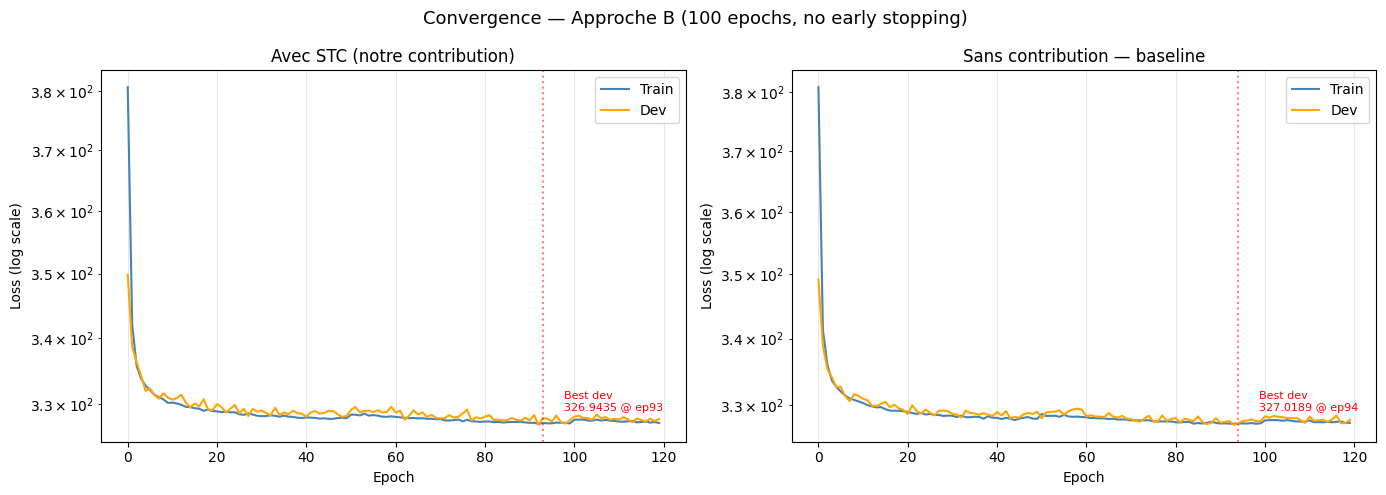

Meilleure dev loss AVEC : 326.9435  @ epoch 93
Meilleure dev loss SANS : 327.0189  @ epoch 94


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in [
    (axes[0], history_with,    'Avec STC (notre contribution)'),
    (axes[1], history_without, 'Sans contribution — baseline')
]:
    ax.plot(hist['train'], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(hist['dev'],   label='Dev',   color='orange',    linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    best_ep = int(np.argmin(hist['dev'])) + 1
    best_v  = min(hist['dev'])
    ax.axvline(best_ep, color='red', linestyle=':', alpha=0.5)
    ax.annotate(f"Best dev\n{best_v:.4f} @ ep{best_ep}",
                xy=(best_ep, best_v), xytext=(15, 10),
                textcoords='offset points', fontsize=8, color='red')

plt.suptitle('Convergence — Approche B (100 epochs, no early stopping)', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_approach_b.png', dpi=150)
plt.show()

print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}  "
      f"@ epoch {np.argmin(history_with['dev'])+1}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}  "
      f"@ epoch {np.argmin(history_without['dev'])+1}")


# Cellule 15 — Courbes de loss comparatives

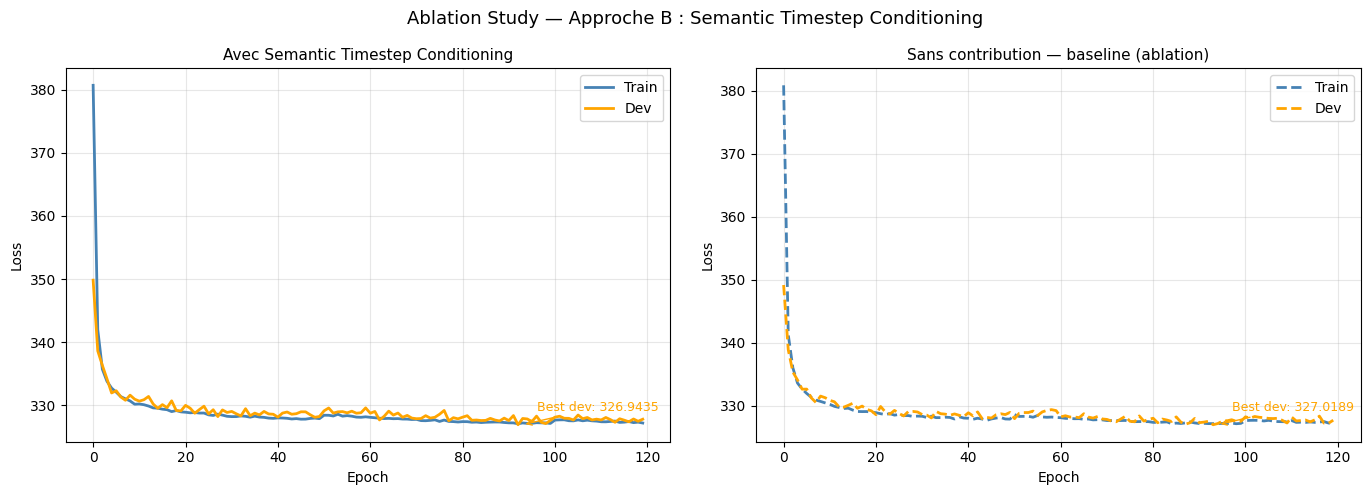

Meilleure dev loss AVEC : 326.9435
Meilleure dev loss SANS : 327.0189
Gain de notre contribution : +0.0754


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with['train'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history_with['dev'],   label='Dev',   color='orange',    linewidth=2)
axes[0].set_title('Avec Semantic Timestep Conditioning', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best dev: {min(history_with['dev']):.4f}",
                 xy=(np.argmin(history_with['dev'])+1, min(history_with['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

axes[1].plot(history_without['train'], label='Train', color='steelblue',
             linewidth=2, linestyle='--')
axes[1].plot(history_without['dev'],   label='Dev',   color='orange',
             linewidth=2, linestyle='--')
axes[1].set_title('Sans contribution — baseline (ablation)', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].annotate(f"Best dev: {min(history_without['dev']):.4f}",
                 xy=(np.argmin(history_without['dev'])+1, min(history_without['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

plt.suptitle('Ablation Study — Approche B : Semantic Timestep Conditioning', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_approach_b.png', dpi=150)
plt.show()

gain = min(history_without['dev']) - min(history_with['dev'])
print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}")
print(f"Gain de notre contribution : {gain:+.4f}")


# Cellule 16 — Vérification des plages de valeurs

In [16]:
batch = next(iter(dev_loader))
gt    = batch['poses']

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("Espace normalisé :")
print(f"  GT    — min: {gt.min():.4f}, max: {gt.max():.4f}, mean: {gt.mean():.4f}")
print(f"  Pred  — min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

mean_np     = stats['mean'].numpy()
std_np      = stats['std'].numpy()
gt_denorm   = gt.numpy()   * std_np + mean_np
pred_denorm = pred.cpu().numpy() * std_np + mean_np

print("\nEspace original (dénormalisé) :")
print(f"  GT    — min: {gt_denorm.min():.4f}, max: {gt_denorm.max():.4f}")
print(f"  Pred  — min: {pred_denorm.min():.4f}, max: {pred_denorm.max():.4f}")


Espace normalisé :
  GT    — min: -3.0000, max: 3.0000, mean: 0.0031
  Pred  — min: -0.9978, max: 0.9978, mean: -0.0018

Espace original (dénormalisé) :
  GT    — min: -0.3301, max: 1.0000
  Pred  — min: -0.2067, max: 0.7479


# Cellule 17 — MPJPE (dénormalisé, par séquence)

In [17]:
@torch.no_grad()
def compute_mpjpe(model, loader, stats, n_samples=200):
    """
    MPJPE en espace dénormalisé.
    Génère chaque séquence avec sa vraie longueur individuelle.
    """
    model.eval()
    mean_t = stats['mean'].to(DEVICE)   # (151, 3)
    std_t  = stats['std'].to(DEVICE)    # (151, 3)
    scores = []
    count  = 0

    for batch in tqdm(loader, desc="MPJPE", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L           = pose_lengths[i].item()
            pred_i      = model.generate(input_ids[i:i+1],
                                         attention_mask[i:i+1],
                                         n_frames=L)           # (1, L, 151, 3)
            gt_i        = gt_poses[i, :L]
            gt_denorm   = gt_i     * std_t + mean_t
            pred_denorm = pred_i[0] * std_t + mean_t
            dist        = torch.norm(pred_denorm - gt_denorm, dim=-1)  # (L, 151)
            scores.append(dist.mean().item())

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# Cellule 18 — DTW (Dynamic Time Warping)

> DTW mesure la similarité temporelle entre deux séquences de longueurs différentes.
> Contrairement à MPJPE (qui compare frame-à-frame), DTW trouve l'alignement optimal
> entre les trajectoires prédite et GT, ce qui est plus adapté aux séquences de gestes
> où les vitesses d'exécution peuvent varier.
>
> **Implémentation :** DTW vectorisé sur les 151 keypoints, calculé en espace dénormalisé.
> On utilise la distance euclidienne entre poses complètes comme coût de distorsion.


In [18]:
def dtw_distance(seq1, seq2):
    """
    DTW entre deux séquences de poses.
    seq1 : (T1, 151, 3) — numpy, espace dénormalisé
    seq2 : (T2, 151, 3) — numpy, espace dénormalisé
    Retourne le coût DTW normalisé par (T1 + T2).
    """
    T1, T2 = len(seq1), len(seq2)

    # Aplatir les poses : (T, 151*3)
    s1 = seq1.reshape(T1, -1).astype(np.float32)
    s2 = seq2.reshape(T2, -1).astype(np.float32)

    # Matrice de coût : distance euclidienne entre chaque paire de frames
    # Vectorisé : évite la double boucle Python
    diff = s1[:, None, :] - s2[None, :, :]          # (T1, T2, D)
    cost = np.sqrt((diff ** 2).sum(axis=-1))         # (T1, T2)

    # Programmation dynamique DTW
    dtw = np.full((T1 + 1, T2 + 1), np.inf, dtype=np.float32)
    dtw[0, 0] = 0.0
    for i in range(1, T1 + 1):
        for j in range(1, T2 + 1):
            dtw[i, j] = cost[i-1, j-1] + min(
                dtw[i-1, j],    # insertion
                dtw[i, j-1],    # deletion
                dtw[i-1, j-1]   # match
            )

    # Normaliser par la longueur du chemin optimal
    return float(dtw[T1, T2]) / (T1 + T2)


@torch.no_grad()
def compute_dtw(model, loader, stats, n_samples=100):
    """
    DTW moyen sur n_samples séquences du loader.
    Moins de samples que MPJPE car DTW est O(T1*T2) en temps.
    """
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)
    mean_t  = stats['mean'].to(DEVICE)
    std_t   = stats['std'].to(DEVICE)

    scores = []
    count  = 0

    for batch in tqdm(loader, desc="DTW", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L = pose_lengths[i].item()

            # Générer la séquence prédite
            pred_i = model.generate(input_ids[i:i+1],
                                    attention_mask[i:i+1],
                                    n_frames=L)            # (1, L, 151, 3) normalisé

            # Dénormaliser
            gt_denorm   = (gt_poses[i, :L]  * std_t + mean_t).cpu().numpy()  # (L, 151, 3)
            pred_denorm = (pred_i[0]         * std_t + mean_t).cpu().numpy()  # (L, 151, 3)

            dtw_score = dtw_distance(pred_denorm, gt_denorm)
            scores.append(dtw_score)

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# Cellule 19 — Calcul des métriques (MPJPE + DTW)

In [19]:
print("Calcul MPJPE...")
mpjpe_with    = compute_mpjpe(model_with,    dev_loader, stats, n_samples=200)
mpjpe_without = compute_mpjpe(model_without, dev_loader, stats, n_samples=200)

print("\nCalcul DTW (plus lent — O(T²) par séquence)...")
dtw_with    = compute_dtw(model_with,    dev_loader, stats, n_samples=100)
dtw_without = compute_dtw(model_without, dev_loader, stats, n_samples=100)

print(f"\n{'='*55}")
print(f"{'Métrique':<20} {'AVEC STC':>12} {'SANS STC':>12} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'MPJPE ↓':<20} {mpjpe_with:>12.4f} {mpjpe_without:>12.4f} "
      f"{mpjpe_without - mpjpe_with:>+10.4f}")
print(f"{'DTW ↓':<20} {dtw_with:>12.4f} {dtw_without:>12.4f} "
      f"{dtw_without - dtw_with:>+10.4f}")
print(f"{'='*55}")
print("↓ = plus bas est mieux | Gain positif = STC aide")


Calcul MPJPE...



Calcul DTW (plus lent — O(T²) par séquence)...



Métrique                 AVEC STC     SANS STC       Gain
-------------------------------------------------------
MPJPE ↓                    0.1093       0.1094    +0.0001
DTW ↓                      0.7565       0.7555    -0.0010
↓ = plus bas est mieux | Gain positif = STC aide


# Cellule 20 — Visualisation des métriques

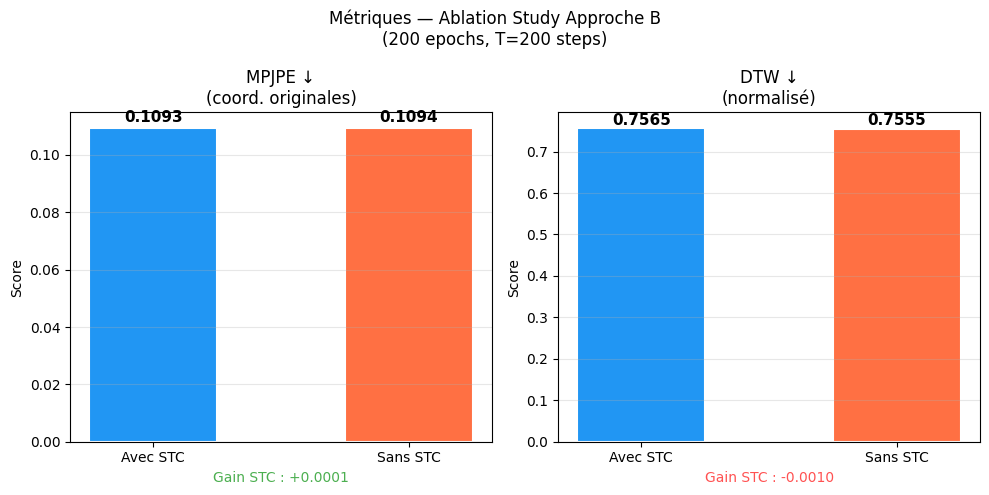

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

metrics = {
    'MPJPE ↓\n(coord. originales)': (mpjpe_with, mpjpe_without),
    'DTW ↓\n(normalisé)':           (dtw_with,   dtw_without),
}

for ax, (metric_name, (val_with, val_without)) in zip(axes, metrics.items()):
    bars = ax.bar(['Avec STC', 'Sans STC'],
                  [val_with, val_without],
                  color=['#2196F3', '#FF7043'],
                  width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [val_with, val_without]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    gain = val_without - val_with
    color = '#4CAF50' if gain > 0 else '#FF5252'
    ax.set_xlabel(f"Gain STC : {gain:+.4f}", color=color, fontsize=10)

plt.suptitle('Métriques — Ablation Study Approche B\n(200 epochs, T=200 steps)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/metrics_approach_b.png', dpi=150)
plt.show()


# Cellule 21 — Visualisation squelettes connectés

In [21]:
# Diagnostic : comparer les distributions GT vs Pred en espace normalisé
batch = next(iter(dev_loader))
gt    = batch['poses']   # (B, T, 151, 3) normalisé

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("=== Espace normalisé ===")
print(f"GT   — mean: {gt.mean():.3f}  std: {gt.std():.3f}  min: {gt.min():.3f}  max: {gt.max():.3f}")
print(f"Pred — mean: {pred.mean():.3f}  std: {pred.std():.3f}  min: {pred.min():.3f}  max: {pred.max():.3f}")

# Si Pred std >> GT std → le modèle génère trop de variance → poses explosées
# Si Pred mean ≠ GT mean → le modèle génère dans la mauvaise plage

=== Espace normalisé ===
GT   — mean: 0.003  std: 0.906  min: -3.000  max: 3.000
Pred — mean: -0.001  std: 0.900  min: -0.997  max: 0.997



──────────────────────────────────────────────────
Visualisation sample 0
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

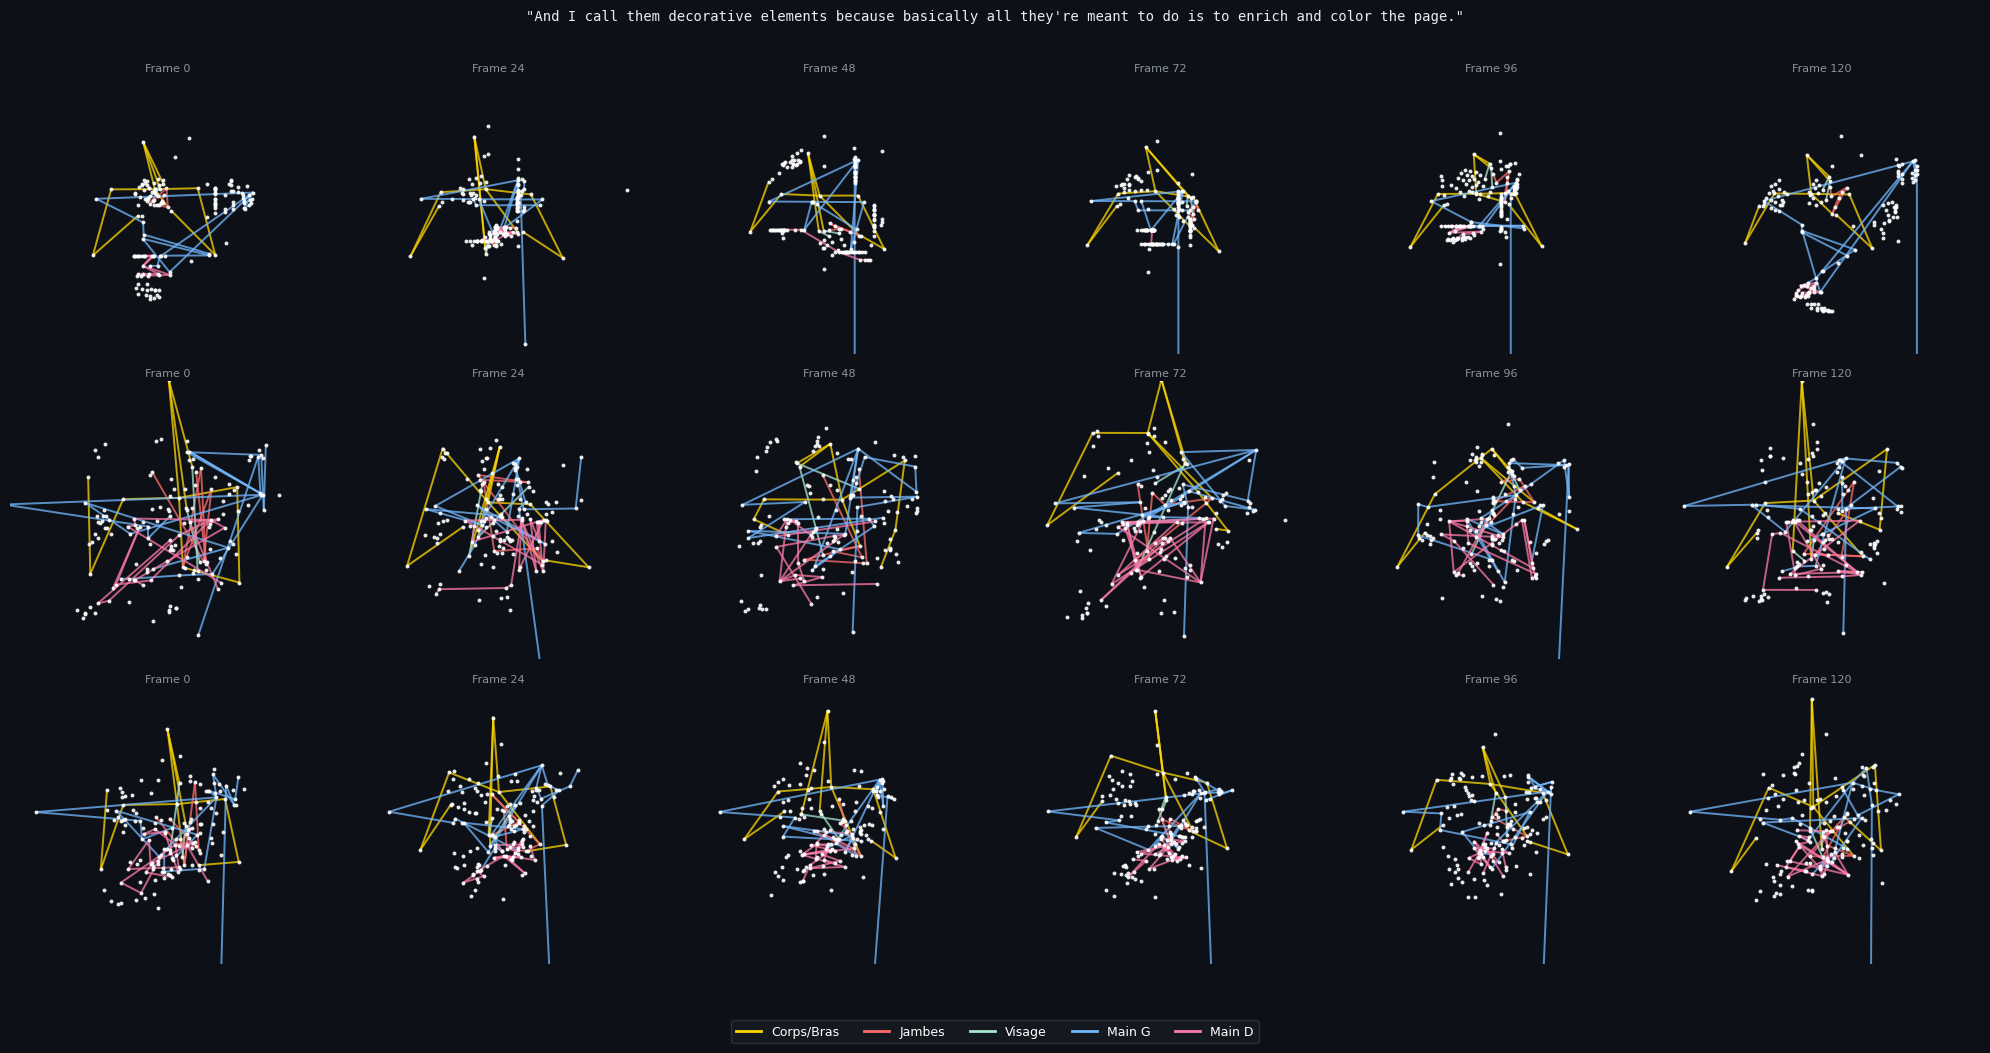

✅ viz_full_0.png sauvegardé


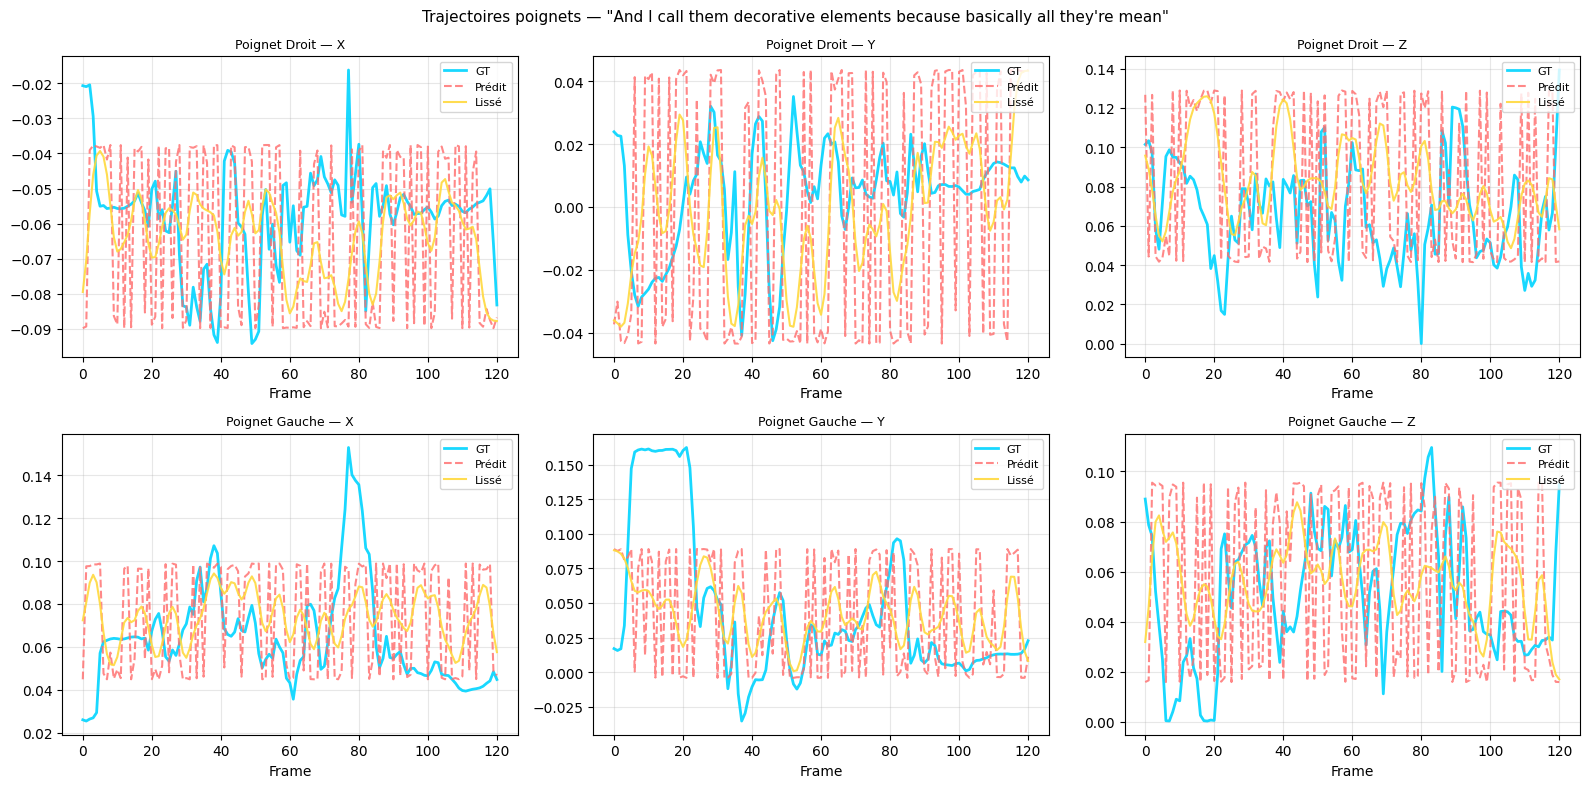

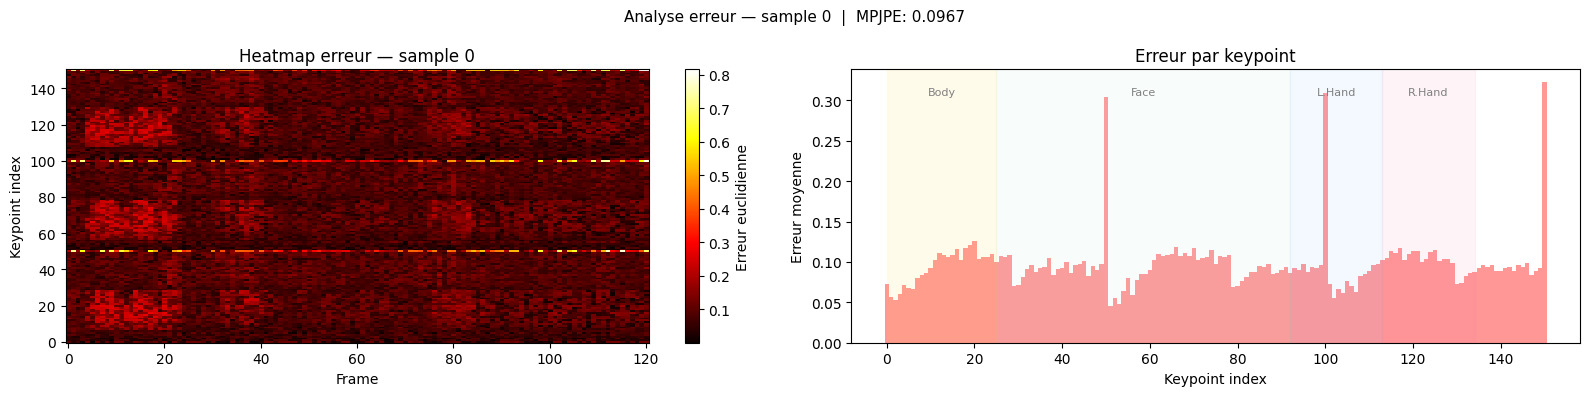

Sample 0 : 121 frames
  MPJPE          : 0.0967
  MPJPE lissé    : 0.0710
  Keypoint pire  : #150 (erreur moy = 0.3222)
  Région pire    : Main D

──────────────────────────────────────────────────
Visualisation sample 5
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

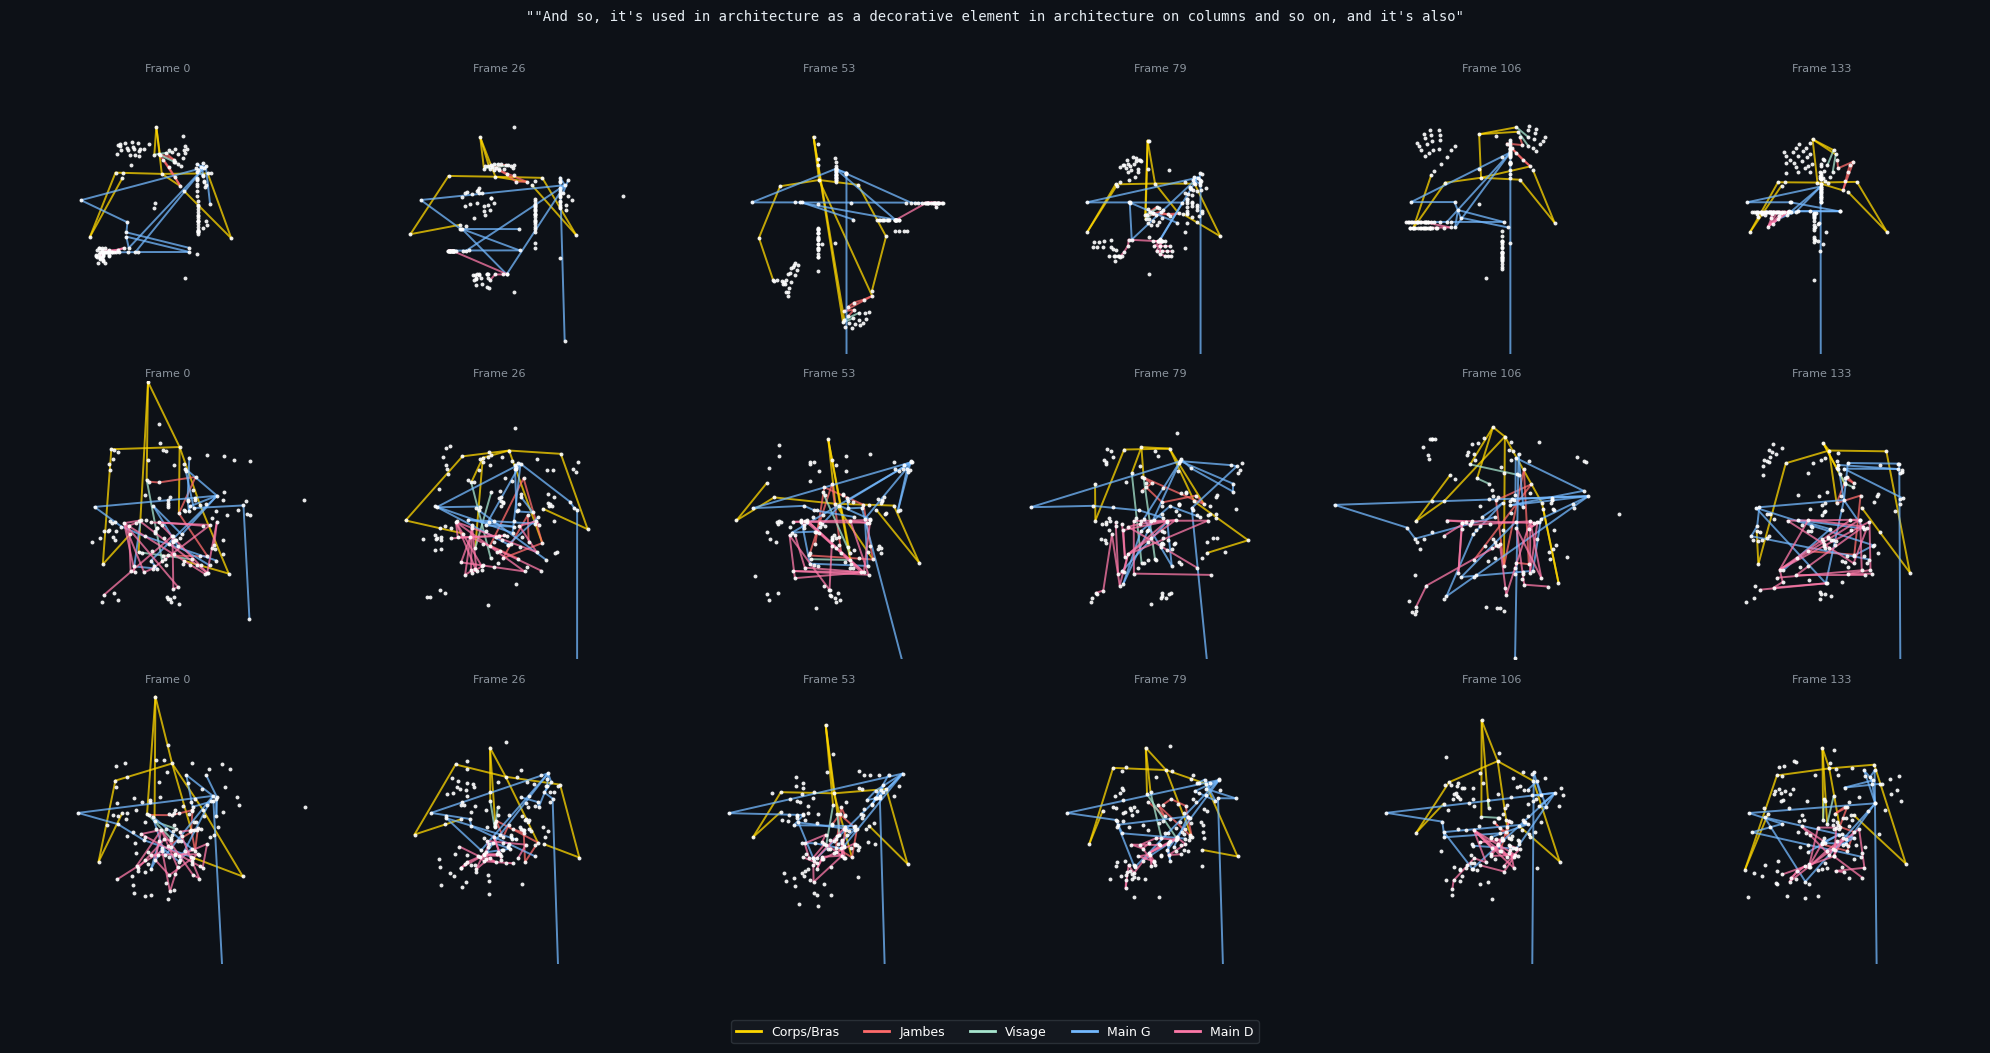

✅ viz_full_5.png sauvegardé


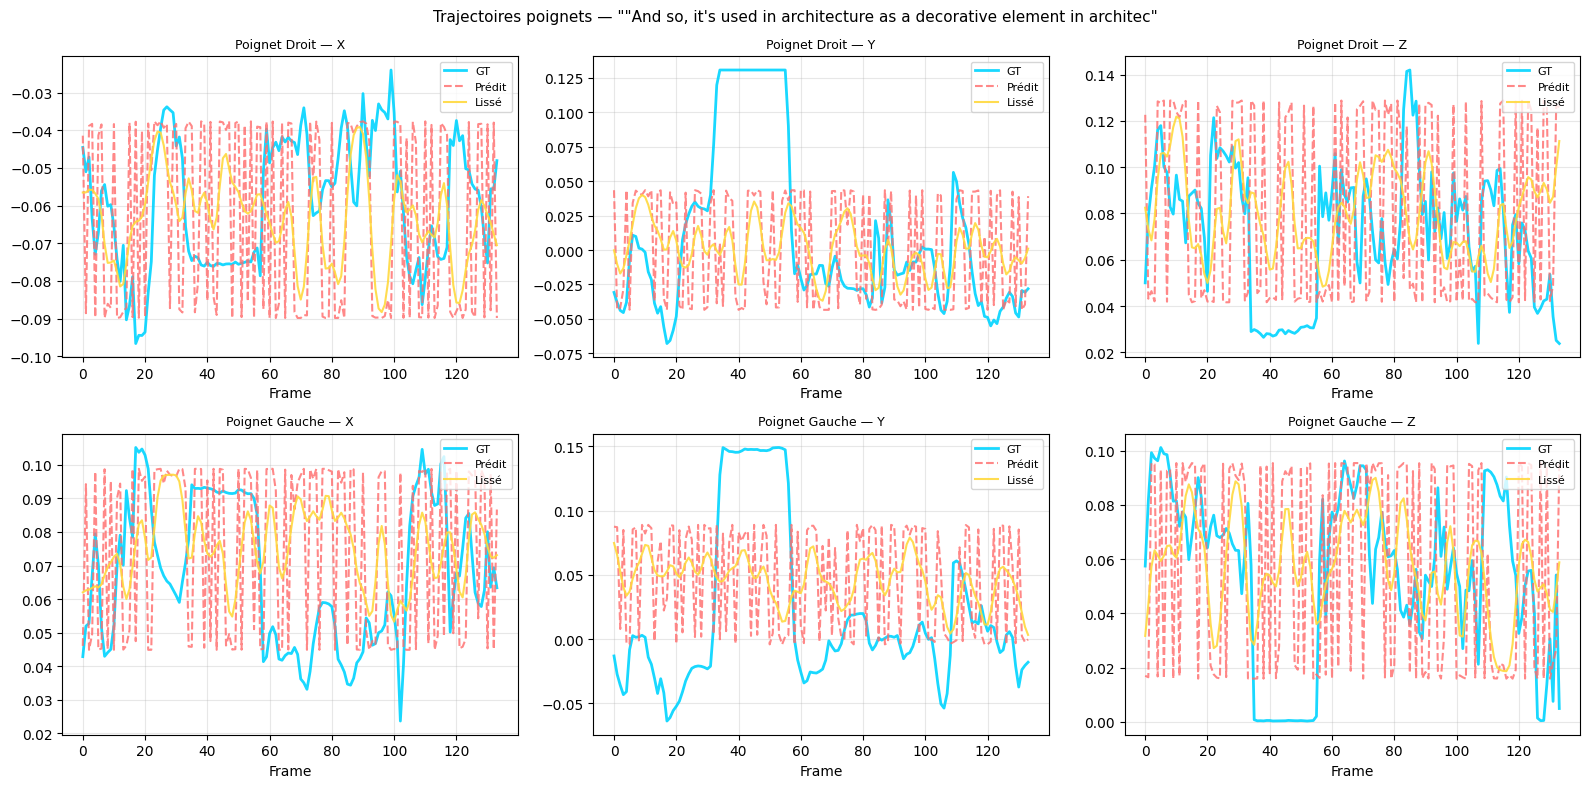

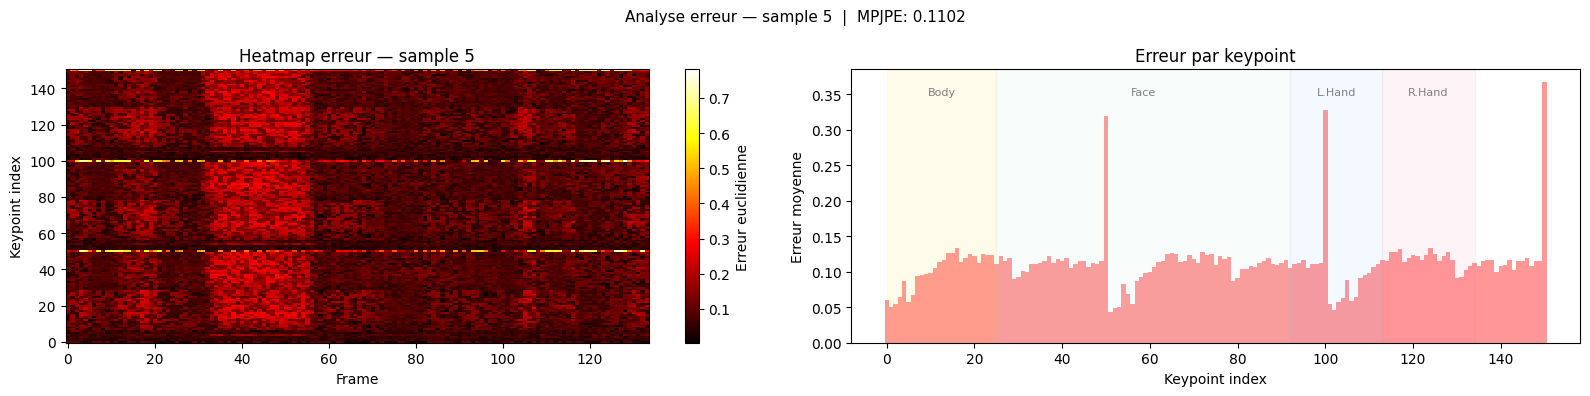

Sample 5 : 134 frames
  MPJPE          : 0.1102
  MPJPE lissé    : 0.0876
  Keypoint pire  : #150 (erreur moy = 0.3666)
  Région pire    : Main D

──────────────────────────────────────────────────
Visualisation sample 10
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

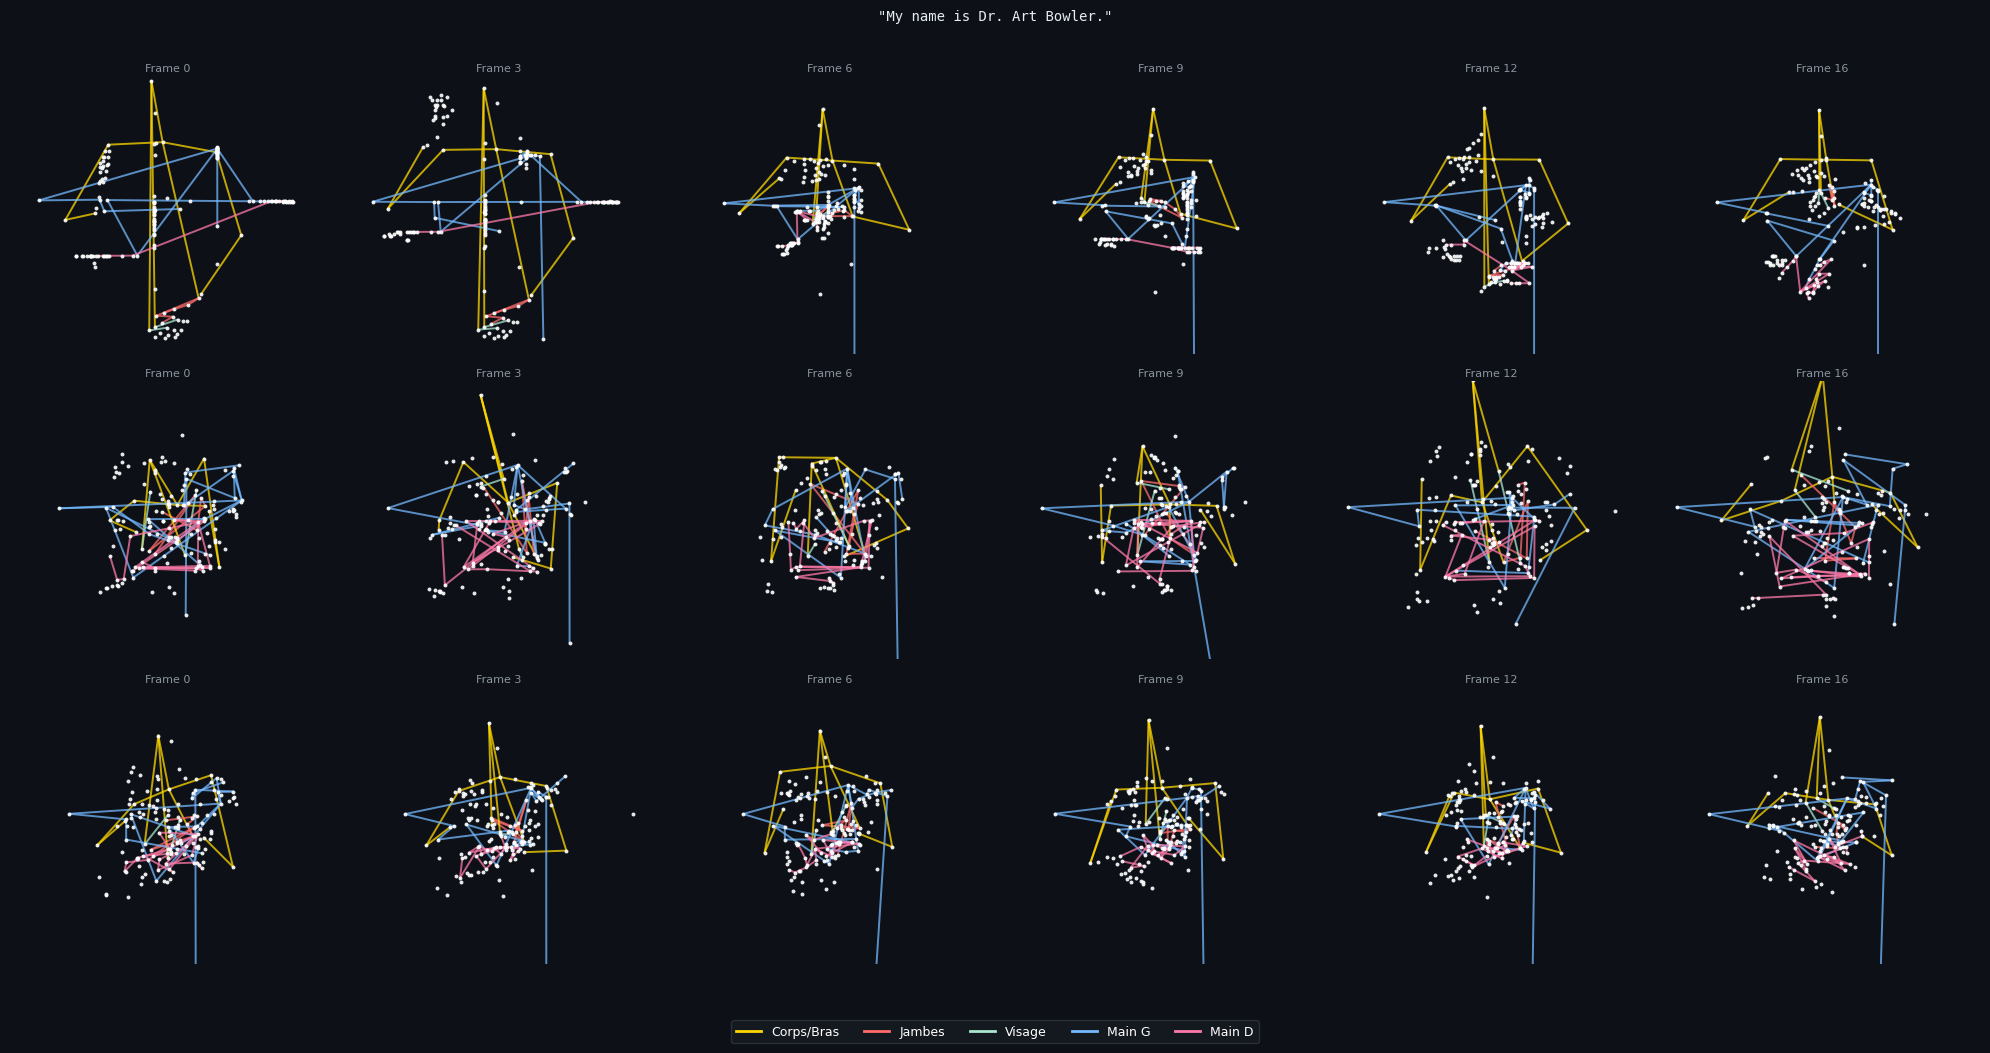

✅ viz_full_10.png sauvegardé


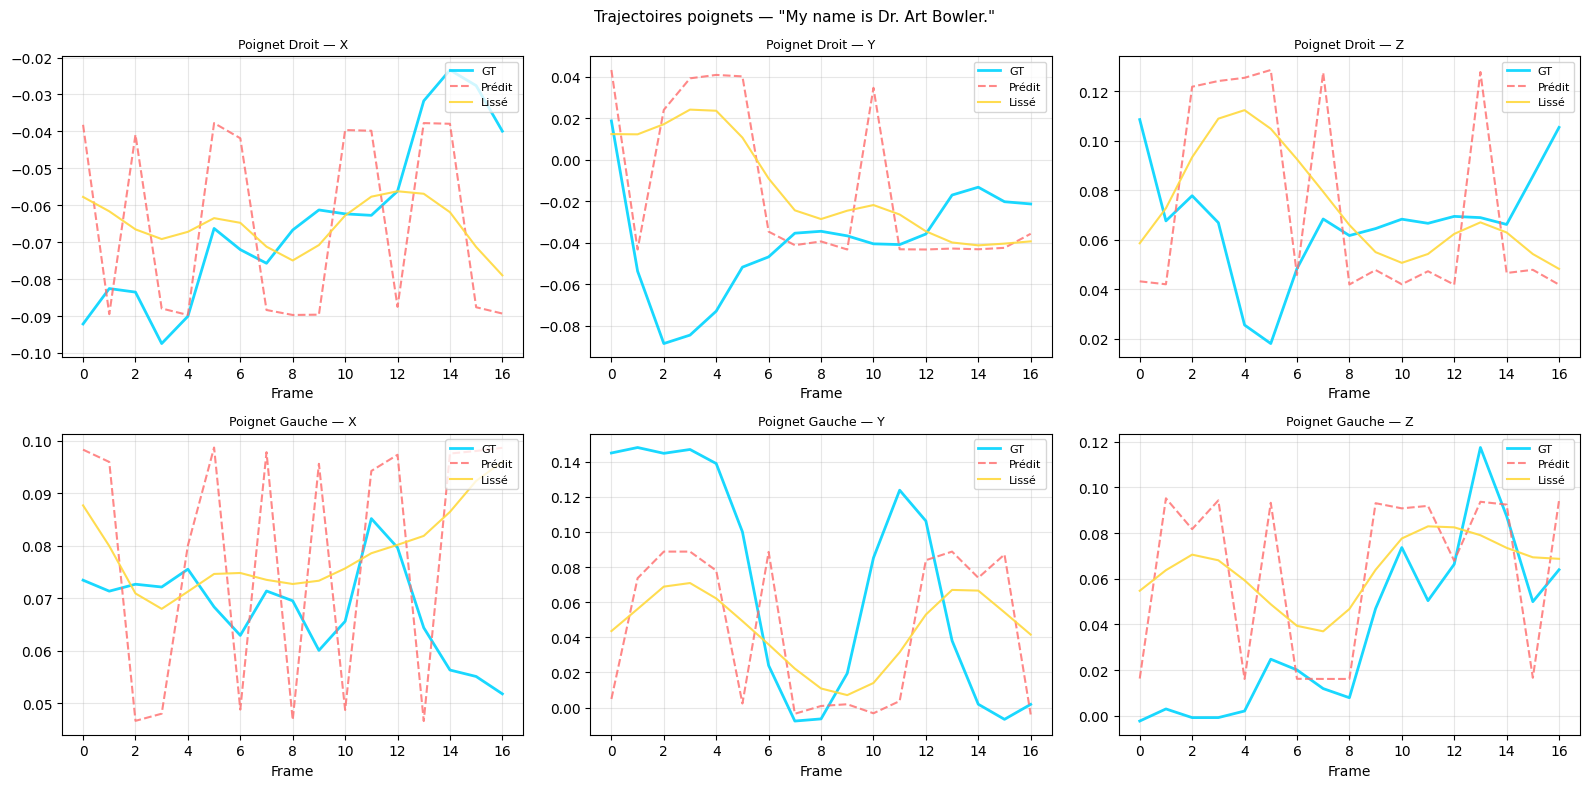

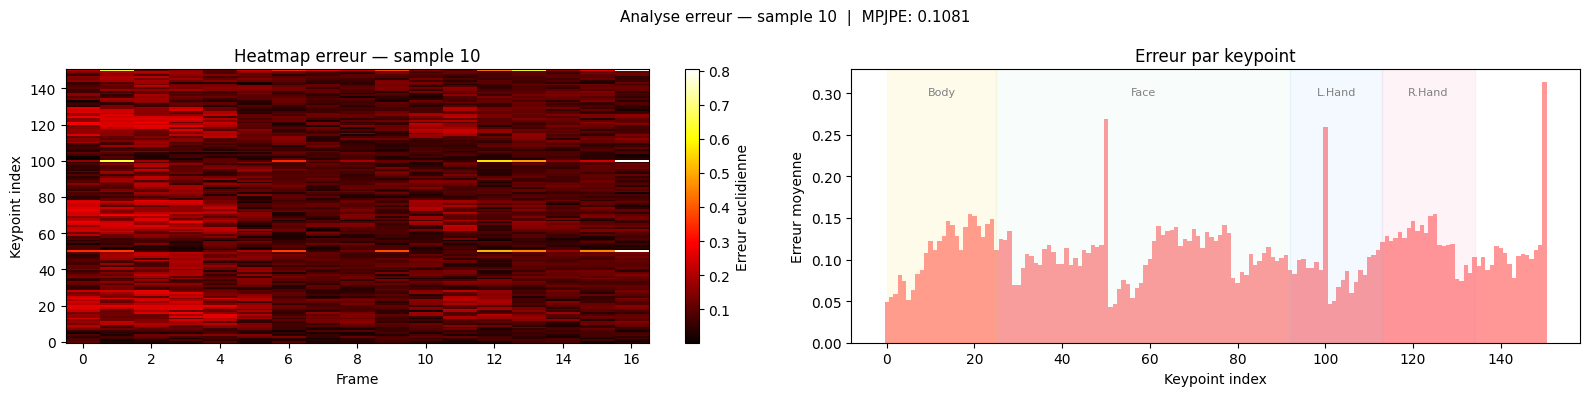

Sample 10 : 17 frames
  MPJPE          : 0.1081
  MPJPE lissé    : 0.0873
  Keypoint pire  : #150 (erreur moy = 0.3130)
  Région pire    : Main D


In [22]:
from scipy.ndimage import gaussian_filter1d

# ── Connexions correctes OpenPose Body25 + mains ──────────────────
BODY_CONNECTIONS = [
    # Torse + bras
    (0, 1),   # nose -> neck
    (1, 2),   # neck -> right shoulder
    (2, 3),   # right shoulder -> right elbow
    (3, 4),   # right elbow -> right wrist
    (1, 5),   # neck -> left shoulder
    (5, 6),   # left shoulder -> left elbow
    (6, 7),   # left elbow -> left wrist
    # Hanches + jambes
    (1, 8),   # neck -> mid hip
    (8, 9),   # mid hip -> right hip
    (9, 10),  # right hip -> right knee
    (10, 11), # right knee -> right ankle
    (8, 12),  # mid hip -> left hip
    (12, 13), # left hip -> left knee
    (13, 14), # left knee -> left ankle
    # Visage
    (0, 15),  # nose -> right eye
    (0, 16),  # nose -> left eye
    (15, 17), # right eye -> right ear
    (16, 18), # left eye -> left ear
    # Main gauche (base = 92)
    (92, 93),  (93, 94),  (94, 95),  (95, 96),   # pouce
    (92, 97),  (97, 98),  (98, 99),  (99, 100),  # index
    (92, 101), (101, 102),(102, 103),(103, 104),  # majeur
    (92, 105), (105, 106),(106, 107),(107, 108),  # annulaire
    (92, 109), (109, 110),(110, 111),(111, 112),  # auriculaire
    # Main droite (base = 113)
    (113, 114),(114, 115),(115, 116),(116, 117),
    (113, 118),(118, 119),(119, 120),(120, 121),
    (113, 122),(122, 123),(123, 124),(124, 125),
    (113, 126),(126, 127),(127, 128),(128, 129),
    (113, 130),(130, 131),(131, 132),(132, 133),
]

# Couleurs par région pour mieux distinguer les parties du corps
REGION_COLORS = {
    'body' : '#FFD700',  # or     — torse/bras
    'legs' : '#FF6B6B',  # rouge  — jambes
    'face' : '#A8E6CF',  # vert   — visage
    'lhand': '#74B9FF',  # bleu   — main gauche
    'rhand': '#FD79A8',  # rose   — main droite
}

def get_connection_color(i, j, default_color):
    """Retourne la couleur selon la région anatomique de la connexion."""
    if i <= 7 or j <= 7:       return REGION_COLORS['body']
    if 8 <= i <= 14 or 8 <= j <= 14:  return REGION_COLORS['legs']
    if 15 <= i <= 24 or 15 <= j <= 24: return REGION_COLORS['face']
    if 92 <= i <= 112 or 92 <= j <= 112: return REGION_COLORS['lhand']
    if 113 <= i <= 133 or 113 <= j <= 133: return REGION_COLORS['rhand']
    return default_color


def smooth_poses(poses, sigma=1.5):
    """Lisse les poses sur la dimension temporelle."""
    smoothed = np.copy(poses)
    for kp in range(poses.shape[1]):
        for coord in range(poses.shape[2]):
            smoothed[:, kp, coord] = gaussian_filter1d(
                poses[:, kp, coord], sigma=sigma
            )
    return smoothed


def compute_global_lims(poses_list, indices):
    """
    Calcule les limites d'affichage communes à partir des GT poses,
    pour que GT / Prédit / Lissé soient sur la même échelle.
    """
    xs = np.concatenate([poses[indices, :, 0].flatten() for poses in poses_list])
    ys = np.concatenate([-poses[indices, :, 1].flatten() for poses in poses_list])
    # Filtrer les outliers extrêmes avant de calculer les limites
    xs = xs[np.isfinite(xs)]
    ys = ys[np.isfinite(ys)]
    x_mid   = np.median(xs)
    y_mid   = np.median(ys)
    spread  = max(np.percentile(np.abs(xs - x_mid), 95),
                  np.percentile(np.abs(ys - y_mid), 95)) * 1.4 + 0.05
    return x_mid, y_mid, spread


def plot_skeleton_connected(ax, frame, default_color='steelblue',
                             alpha=0.8, lims=None, use_region_colors=True):
    """
    Dessine un squelette connecté sur ax.
    lims = (x_mid, y_mid, spread) — limites communes pour comparaison équitable.
    """
    xs = frame[:, 0]
    ys = -frame[:, 1]   # inverser Y car coordonnées image (Y vers le bas)

    # Appliquer les limites communes ou calculer localement
    if lims is not None:
        x_mid, y_mid, spread = lims
    else:
        x_mid  = np.median(xs[np.isfinite(xs)])
        y_mid  = np.median(ys[np.isfinite(ys)])
        spread = max(np.nanstd(xs), np.nanstd(ys)) * 3 + 0.05

    ax.set_xlim(x_mid - spread, x_mid + spread)
    ax.set_ylim(y_mid - spread, y_mid + spread)

    # Dessiner les connexions avec couleurs par région
    for (i, j) in BODY_CONNECTIONS:
        if i < len(frame) and j < len(frame):
            if not (np.isfinite(xs[i]) and np.isfinite(xs[j])
                    and np.isfinite(ys[i]) and np.isfinite(ys[j])):
                continue
            color = get_connection_color(i, j, default_color) \
                    if use_region_colors else default_color
            ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                    c=color, alpha=0.75, linewidth=1.4, zorder=2, solid_capstyle='round')

    # Dessiner les keypoints par-dessus
    ax.scatter(xs, ys, s=8, c='white', alpha=0.9, zorder=3, linewidths=0)

    ax.axis('off')
    ax.set_aspect('equal', adjustable='datalim')


@torch.no_grad()
def visualize_full(model, dataset, stats, idx=0):
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)

    sample         = dataset[idx]
    input_ids      = sample['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(DEVICE)
    gt_norm        = sample['poses'].numpy()          # (T, 151, 3) normalisé
    text           = sample['text']
    n_frames       = gt_norm.shape[0]

    # Générer les poses prédites
    pred_norm     = model.generate(input_ids, attention_mask,
                                   n_frames=n_frames)[0].cpu().numpy()

    # Dénormaliser vers l'espace original
    gt_poses      = gt_norm   * std_np + mean_np      # (T, 151, 3)
    pred_poses    = pred_norm * std_np + mean_np

    
    pred_smoothed = smooth_poses(pred_poses, sigma=1.5)

    n_show  = 6
    indices = np.linspace(0, min(len(gt_poses), len(pred_poses)) - 1,
                          n_show, dtype=int)

    # Limites communes calculées sur GT + Pred pour échelle cohérente
    global_lims = compute_global_lims([gt_poses, pred_poses], indices)

    # ── Plot 1 : Squelettes GT / Prédit / Lissé ─────────────────
    fig, axes = plt.subplots(3, n_show, figsize=(20, 10), facecolor='#0d1117')
    fig.suptitle(f'"{text[:110]}"', fontsize=10, color='#e6edf3',
                 y=1.01, fontfamily='monospace')

    row_labels = ['Ground Truth', 'Généré (brut)', 'Généré (lissé)']
    row_data   = [gt_poses, pred_poses, pred_smoothed]

    for col, fi in enumerate(indices):
        for row, (poses, label) in enumerate(zip(row_data, row_labels)):
            ax = axes[row, col]
            ax.set_facecolor('#0d1117')
            plot_skeleton_connected(ax, poses[fi], lims=global_lims,
                                    use_region_colors=True)
            ax.set_title(f'Frame {fi}', fontsize=8, color='#8b949e', pad=3)
            if col == 0:
                colors_row = ['#00d4ff', '#ff6b6b', '#ffd93d']
                ax.set_ylabel(label, fontsize=9, color=colors_row[row],
                              fontweight='bold', labelpad=4)

    # Légende des couleurs par région
    legend_elements = [
        plt.Line2D([0], [0], color=REGION_COLORS['body'],  lw=2, label='Corps/Bras'),
        plt.Line2D([0], [0], color=REGION_COLORS['legs'],  lw=2, label='Jambes'),
        plt.Line2D([0], [0], color=REGION_COLORS['face'],  lw=2, label='Visage'),
        plt.Line2D([0], [0], color=REGION_COLORS['lhand'], lw=2, label='Main G'),
        plt.Line2D([0], [0], color=REGION_COLORS['rhand'], lw=2, label='Main D'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               facecolor='#161b22', edgecolor='#30363d',
               labelcolor='white', fontsize=9, bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(f'/kaggle/working/viz_full_{idx}.png',
                dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✅ viz_full_{idx}.png sauvegardé")

    # ── Plot 2 : Trajectoire temporelle des poignets ─────────────
    # Keypoints 4 (poignet droit) et 7 (poignet gauche) — les plus informatifs en ASL
    fig, axes2 = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f'Trajectoires poignets — "{text[:70]}"', fontsize=11)

    wrist_kps = [(4, 'Poignet Droit'), (7, 'Poignet Gauche')]
    coords    = ['X', 'Y', 'Z']

    for row, (kp_idx, kp_name) in enumerate(wrist_kps):
        for col, coord_name in enumerate(coords):
            ax = axes2[row, col]
            ax.plot(gt_poses[:, kp_idx, col],
                    color='#00d4ff', linewidth=2, label='GT', alpha=0.9)
            ax.plot(pred_poses[:, kp_idx, col],
                    color='#ff6b6b', linewidth=1.5, linestyle='--',
                    label='Prédit', alpha=0.8)
            ax.plot(pred_smoothed[:, kp_idx, col],
                    color='#ffd93d', linewidth=1.5,
                    label='Lissé', alpha=0.9)
            ax.set_title(f'{kp_name} — {coord_name}', fontsize=9)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(alpha=0.3)
            ax.set_xlabel('Frame')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/trajectory_{idx}.png', dpi=150)
    plt.show()

    # ── Plot 3 : Heatmap erreur par keypoint ────────────────────
    min_T  = min(len(gt_poses), len(pred_poses))
    errors = np.linalg.norm(pred_poses[:min_T] - gt_poses[:min_T], axis=-1)  # (T, 151)

    fig, axes3 = plt.subplots(1, 2, figsize=(16, 4))

    im = axes3[0].imshow(errors.T, aspect='auto', cmap='hot',
                          interpolation='nearest', origin='lower')
    plt.colorbar(im, ax=axes3[0], label='Erreur euclidienne')
    axes3[0].set_xlabel('Frame'); axes3[0].set_ylabel('Keypoint index')
    axes3[0].set_title(f'Heatmap erreur — sample {idx}')

    # Erreur moyenne par keypoint
    mean_err_per_kp = errors.mean(axis=0)   # (151,)
    axes3[1].bar(range(151), mean_err_per_kp, color='#ff6b6b', alpha=0.7, width=1.0)
    axes3[1].set_xlabel('Keypoint index')
    axes3[1].set_ylabel('Erreur moyenne')
    axes3[1].set_title('Erreur par keypoint')
    # Annoter les régions
    for label, (start, end) in [('Body', (0,25)), ('Face', (25,92)),
                                  ('L.Hand', (92,113)), ('R.Hand', (113,134))]:
        axes3[1].axvspan(start, end, alpha=0.08,
                          color=['#FFD700','#A8E6CF','#74B9FF','#FD79A8'][
                              ['Body','Face','L.Hand','R.Hand'].index(label)])
        axes3[1].text((start+end)/2, mean_err_per_kp.max()*0.95,
                       label, ha='center', fontsize=8, color='gray')

    plt.suptitle(f'Analyse erreur — sample {idx}  |  MPJPE: {errors.mean():.4f}',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/heatmap_{idx}.png', dpi=150)
    plt.show()

    # ── Stats ─────────────────────────────────────────────────────
    worst_kp  = mean_err_per_kp.argmax()
    print(f"Sample {idx} : {n_frames} frames")
    print(f"  MPJPE          : {errors.mean():.4f}")
    print(f"  MPJPE lissé    : {np.linalg.norm(pred_smoothed[:min_T] - gt_poses[:min_T], axis=-1).mean():.4f}")
    print(f"  Keypoint pire  : #{worst_kp} (erreur moy = {mean_err_per_kp[worst_kp]:.4f})")
    region = ('Body' if worst_kp < 25 else 'Face' if worst_kp < 92
              else 'Main G' if worst_kp < 113 else 'Main D')
    print(f"  Région pire    : {region}")


# ── Lancer la visualisation ────────────────────────────────────────
for idx in [0, 5, 10]:
    print(f"\n{'─'*50}")
    print(f"Visualisation sample {idx}")
    print(f"{'─'*50}")
    visualize_full(model_with, train_ds, stats, idx=idx)

# Cellule 22 — Sauvegarder résultats et push

In [23]:
import os

output_dir = '/kaggle/working/outputs_approach_b'
os.makedirs(output_dir, exist_ok=True)

torch.save(model_with.state_dict(),
           f'{output_dir}/model_with_contribution.pt')
torch.save(model_without.state_dict(),
           f'{output_dir}/model_without_contribution.pt')
print("✅ Checkpoints sauvegardés")

with open(f'{output_dir}/history_with.json', 'w') as f:
    json.dump(history_with, f)
with open(f'{output_dir}/history_without.json', 'w') as f:
    json.dump(history_without, f)
print("✅ Historiques de loss sauvegardés")

results_path = f'{output_dir}/results_approach_b.csv'
rows = [
    {
        'approach'       : 'B_with_contribution',
        'description'    : 'DDPM + STC (T=200, 120 epochs, base_ch=128)',
        'best_train_loss': round(min(history_with['train']),    4),
        'best_dev_loss'  : round(min(history_with['dev']),      4),
        'mpjpe_dev'      : round(mpjpe_with,                    4),
        'dtw_dev'        : round(dtw_with,                      4),
        'best_epoch'     : int(np.argmin(history_with['dev']) + 1),
    },
    {
        'approach'       : 'B_without_contribution',
        'description'    : 'DDPM baseline ablation (T=200, 120 epochs, base_ch=128)',
        'best_train_loss': round(min(history_without['train']), 4),
        'best_dev_loss'  : round(min(history_without['dev']),   4),
        'mpjpe_dev'      : round(mpjpe_without,                 4),
        'dtw_dev'        : round(dtw_without,                   4),
        'best_epoch'     : int(np.argmin(history_without['dev']) + 1),
    }
]
with open(results_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("✅ results_approach_b.csv sauvegardé")

print(f"\n{'='*55}")
print(f"Résultats finaux :")
print(f"  MPJPE AVEC STC : {mpjpe_with:.4f}")
print(f"  MPJPE SANS STC : {mpjpe_without:.4f}")
print(f"  DTW   AVEC STC : {dtw_with:.4f}")
print(f"  DTW   SANS STC : {dtw_without:.4f}")
print(f"{'='*55}")

print(f"\nFichiers dans {output_dir}:")
for fname in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f'{output_dir}/{fname}') / 1024
    print(f"  {fname:50s} {size:8.1f} KB")


✅ Checkpoints sauvegardés
✅ Historiques de loss sauvegardés
✅ results_approach_b.csv sauvegardé

Résultats finaux :
  MPJPE AVEC STC : 0.1093
  MPJPE SANS STC : 0.1094
  DTW   AVEC STC : 0.7565
  DTW   SANS STC : 0.7555

Fichiers dans /kaggle/working/outputs_approach_b:
  history_with.json                                       4.6 KB
  history_without.json                                    4.6 KB
  model_with_contribution.pt                         203439.8 KB
  model_without_contribution.pt                      203440.3 KB
  results_approach_b.csv                                  0.3 KB
